In [1]:
#%%
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, FuncFormatter, LogFormatterSciNotation
import numpy as np
import math

In [2]:
"""
for each dataset
plot 
    1 graph with
        combined recall v recall
        single graph recall v recall
    1 graph with
        combined dist comp v recall
        single dist comp v recall
    1 graph with 
        overlap v efs? m?
"""

'\nfor each dataset\nplot \n    1 graph with\n        combined recall v recall\n        single graph recall v recall\n    1 graph with\n        combined dist comp v recall\n        single dist comp v recall\n    1 graph with \n        overlap v efs? m?\n'

In [3]:
def loaddata(filename):
    arr = np.loadtxt(filename, delimiter=',', skiprows=1) # d,efc,m,efs,k,recall,distcountsearch
    return { # d,efc,m,efs,k,lp50,lp99,lave,dp50,dp99,dave,hp50,hp99,have,rp50,rp99,rave
        'd':                arr[:, 0],
        'efc':              arr[:, 1],
        'm':                arr[:, 2],
        'efs':              arr[:, 3],
        'k':                arr[:, 4],
        'lp50':             arr[:, 5],
        'lp99':             arr[:, 6],
        'lave':             arr[:, 7],
        'dp50':             arr[:, 8],
        'dp99':             arr[:, 9],
        'dave':             arr[:, 10],
        'hp50':             arr[:, 11],
        'hp99':             arr[:, 12],
        'have':             arr[:, 13],
        'rp50':             arr[:, 14],
        'rp99':             arr[:, 15],
        'recall':           arr[:, 16],
    }

# for M123456
def loaddatam(filename):
    arr = np.loadtxt(filename, delimiter=',', skiprows=1) # d,efc,m,efs,k,recall,distcountsearch
    return { # d,efc,m,efs,k,lp50,lp99,lave,dp50,dp99,dave,hp50,hp99,have,rp50,rp99,rave
        'd':                arr[:, 0],
        'efc':              arr[:, 1],
        'm':                arr[:, 2],
        'efs':              arr[:, 3],
        'k':                arr[:, 4],
        'dcbudget':         arr[:, 5],
        'lp50':             arr[:, 6],
        'lp99':             arr[:, 7],
        'lave':             arr[:, 8],
        'dp50':             arr[:, 9],
        'dp99':             arr[:, 10],
        'dave':             arr[:, 11],
        'op50':             arr[:, 12],
        'op99':             arr[:, 13],
        'oave':             arr[:, 14],
        'rp50':             arr[:, 15],
        'rp99':             arr[:, 16],
        'recall':           arr[:, 17],
    }

# for M78
def loaddatamc(filename):
    arr = np.loadtxt(filename, delimiter=',', skiprows=1) # d,efc,m,efs,k,recall,distcountsearch
    return { # d,efc,m,efs,k,lp50,lp99,lave,dp50,dp99,dave,hp50,hp99,have,rp50,rp99,rave
        'd':                arr[:, 0],
        'efc':              arr[:, 1],
        'm':                arr[:, 2],
        'efs':              arr[:, 3],
        'k':                arr[:, 4],
        'dcbudget':         arr[:, 5],
        'lp50':             arr[:, 6],
        'lp99':             arr[:, 7],
        'lave':             arr[:, 8],
        'dp50':             arr[:, 9],
        'dp99':             arr[:, 10],
        'dave':             arr[:, 11],
        'op50':             arr[:, 12],
        'op99':             arr[:, 13],
        'oave':             arr[:, 14],
        'rp50':             arr[:, 15],
        'rp99':             arr[:, 16],
        'recall':           arr[:, 17],
        'c1p50':            arr[:, 18],
        'c1p99':            arr[:, 19],
        'c1ave':            arr[:, 20],
        'c2p50':            arr[:, 21],
        'c2p99':            arr[:, 22],
        'c2ave':            arr[:, 23],
    }

In [4]:
# plot full optimization matching results
datasets = {
    'deep':         ("deep-image-96-angular", 32),
    # 'gist':       ("gist-960-euclidean", 32),
    'glove-100':    ("glove-100-angular", 40),
    'glove-200':    ("glove-200-angular", 48),
    # 'mnist':      ("mnist-784-euclidean", 8),
    'nytimes':      ("nytimes-256-angular", 32),
    'sift':         ("sift-128-euclidean", 16),
}

In [9]:
# function for plotting graphs to compare normal model, m5, m7, m8
def plot_m5_varyM(datasets):
    # 1 dataset per set
    for dataset_name, (dataset_fullname, M) in datasets.items():

        # 1 param per graph
        # 1 param per graph
        metrics = {
            'l': "latency",
            'd': "distance_computation",
            'o': "overlap rate",
        }

        # 1 run per line >> select/load data for each line
        data = {}            
        data["hnsw"] = loaddata(f"data/hnsw-n-{dataset_fullname}-opt.txt")
        
        m_fac = [0.125, 0.25, 0.5, 1, 2]
        for fac in m_fac:
            key_name = f"hnsw-m5-M{int(M*fac)}"
            data[key_name] = loaddatam(f"data/hnsw-m5-{dataset_fullname}-M{int(M*fac)}-opt.txt")
        
        linecolor = [
            "#fc032c",
            
            "#f06800",
            "#b50db2",
            "#3600e6",
            "#00bfe6",
            "#42f5aa",
            # "#0c6b43",
        ]

        # 2 types of lines
        lineweights = [0.2, 0.2, 0.7]
        linestyles = ['-', ':', '-']
        percentiles = [ 'ave' ]# 'p50', 'p99', 
        marker = 'x'

        # set x 
        xkey = "recall"
        
        # for each plot
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        for (key,value), ax in zip(metrics.items(), (ax1, ax2, ax3)):

            # third plot only shows hnsw-m and hnsw-m2
            if ax == ax3:  
                first_set = next(iter(data))
                data_to_plot = {k: v for k, v in data.items() if k != first_set}
                colors_to_use = linecolor[1:]  # Skip first color
            else:  # First and second plots - show all data
                data_to_plot = data
                colors_to_use = linecolor

            # for each run = each line
            for (run, run_data), color in zip(data_to_plot.items(), colors_to_use):
                for linestyle, percentile, lineweight in zip(linestyles, percentiles, lineweights):
                    
                    ykey = f"{key}{percentile}"

                    # define x array
                    x = run_data[xkey]
                    # define y array
                    y = run_data[ykey]

                    # plot
                    ax.plot(x, y, marker=marker, color=color, label=f'{run}-{percentile}', alpha=lineweight, linestyle=linestyle)

            plottitle = f'{dataset_name}_{value}'

            ax.set_xlabel('Recall')
            ax.set_ylabel(value)
            ax.set_title(plottitle)
            ax.legend()

        # save/show
        fig.tight_layout()
        fig.show()
        # fig.savefig(f'{plottitle}.png', dpi=300, bbox_inches='tight')

In [13]:
# function for plotting graphs to compare normal model, m5, m7, m8
def plot_n_m578(datasets):
    # 1 dataset per set
    for dataset_name, (dataset_fullname, M) in datasets.items():

        # 1 param per graph
        # 1 param per graph
        metrics = {
            'l': "latency",
            'd': "distance_computation",
            'o': "overlap rate",
            'c': "cache miss rate",
        }

        # 1 run per line, 1 color per line
        data = {}            
        data["hnsw"] = loaddata(f"data/hnsw-n-{dataset_fullname}-opt.txt")
        data["hnsw-m5"] = loaddatam(f"data/hnsw-m5-{dataset_fullname}-M{int(M/2)}-opt.txt")
        data["hnsw-m7"] = loaddatamc(f"data/hnsw-m7-{dataset_fullname}-M{int(M/2)}-opt.txt")
        data["hnsw-m8"] = loaddatamc(f"data/hnsw-m8-{dataset_fullname}-M{int(M/2)}-opt.txt")
        linecolor = [
            "#fc032c",
            
            # "#f06800",
            # "#b50db2",
            "#3600e6",
            "#00bfe6",
            # "#42f5aa",
            "#0c6b43",
        ]

        # 3 types of lines, p50, p99, ave, 1 property setting for each
        lineweights = [0.7, 0.7, 0.2]
        linestyles = ['-', ':', '-']
        percentiles = [ 'ave' ] # 'p50', 'p99', 
        marker = 'x'

        # set x 
        xkey = "recall"
        
        # for each plot
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 5))
        for (key,value), ax in zip(metrics.items(), (ax1, ax2, ax3, ax4)):

            # skip normal graph if plotting overlap
            if key == "o":  
                data_to_plot = {"hnsw-m5": data["hnsw-m5"], "hnsw-m7": data["hnsw-m7"], "hnsw-m8": data["hnsw-m8"]}
                colors_to_use = [linecolor[1], linecolor[2], linecolor[3]]  # Skip first color
            # skip normal graph and m5 if plotting cache miss
            elif key == "c":  
                data_to_plot = {"hnsw-m7": data["hnsw-m7"], "hnsw-m8": data["hnsw-m8"]}
                colors_to_use = [linecolor[2], linecolor[3]]  # Skip first color
            # latency and dist comp - show all data
            else:  
                data_to_plot = data
                colors_to_use = linecolor

            # for each run = each line
            for (run, run_data), color in zip(data_to_plot.items(), colors_to_use):
                for linestyle, percentile, lineweight in zip(linestyles, percentiles, lineweights):

                    # define x array
                    x = run_data[xkey]

                    if key != "c":
                        #define y array
                        ykey = f"{key}{percentile}"
                        y = run_data[ykey]

                        # plot
                        ax.plot(x, y, marker=marker, color=color, label=f'{run}-{percentile}', alpha=lineweight, linestyle=linestyle)

                    else:
                        #define y array
                        ykey1 = f"{key}1{percentile}"
                        ykey2 = f"{key}2{percentile}"
                        y1 = run_data[ykey1]
                        y2 = run_data[ykey2]

                        # plot
                        ax.plot(x, y1, marker=marker, color=color, label=f'{run}-g1{percentile}', alpha=lineweight, linestyle=linestyle)
                        ax.plot(x, y2, marker=marker, color=color, label=f'{run}-g2{percentile}', alpha=lineweight*0.2, linestyle=linestyle)


            plottitle = f'{dataset_name}_{value}'

            ax.set_xlabel('Recall')
            ax.set_ylabel(value)
            ax.set_title(plottitle)
            ax.legend()

        # save/show
        fig.tight_layout()
        fig.show()
        # fig.savefig(f'{plottitle}.png', dpi=300, bbox_inches='tight')

In [14]:
# plot_m5_varyM(datasets)

C:\Users\Katherine\AppData\Local\Temp\ipykernel_21888\3429565124.py:94: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


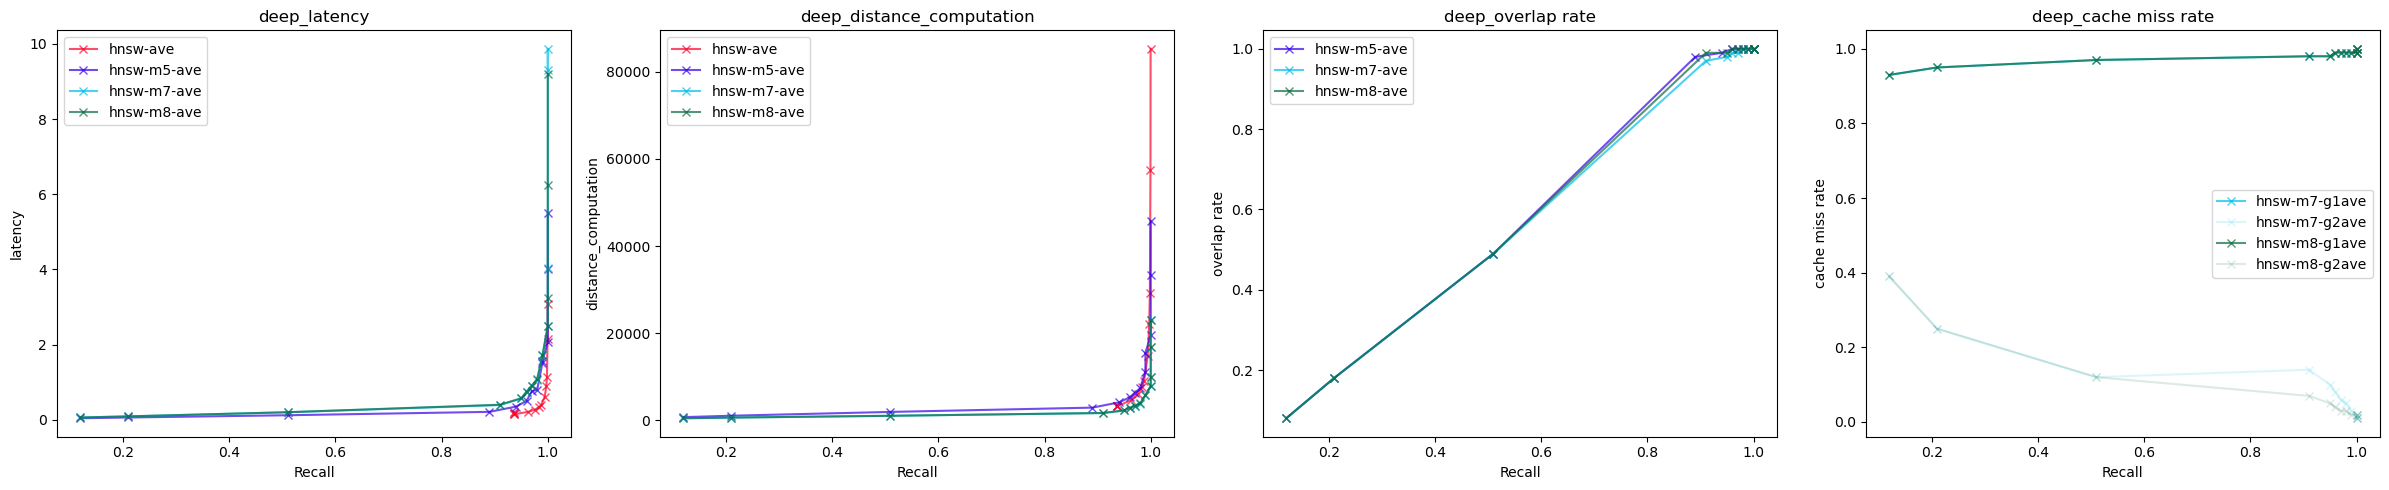

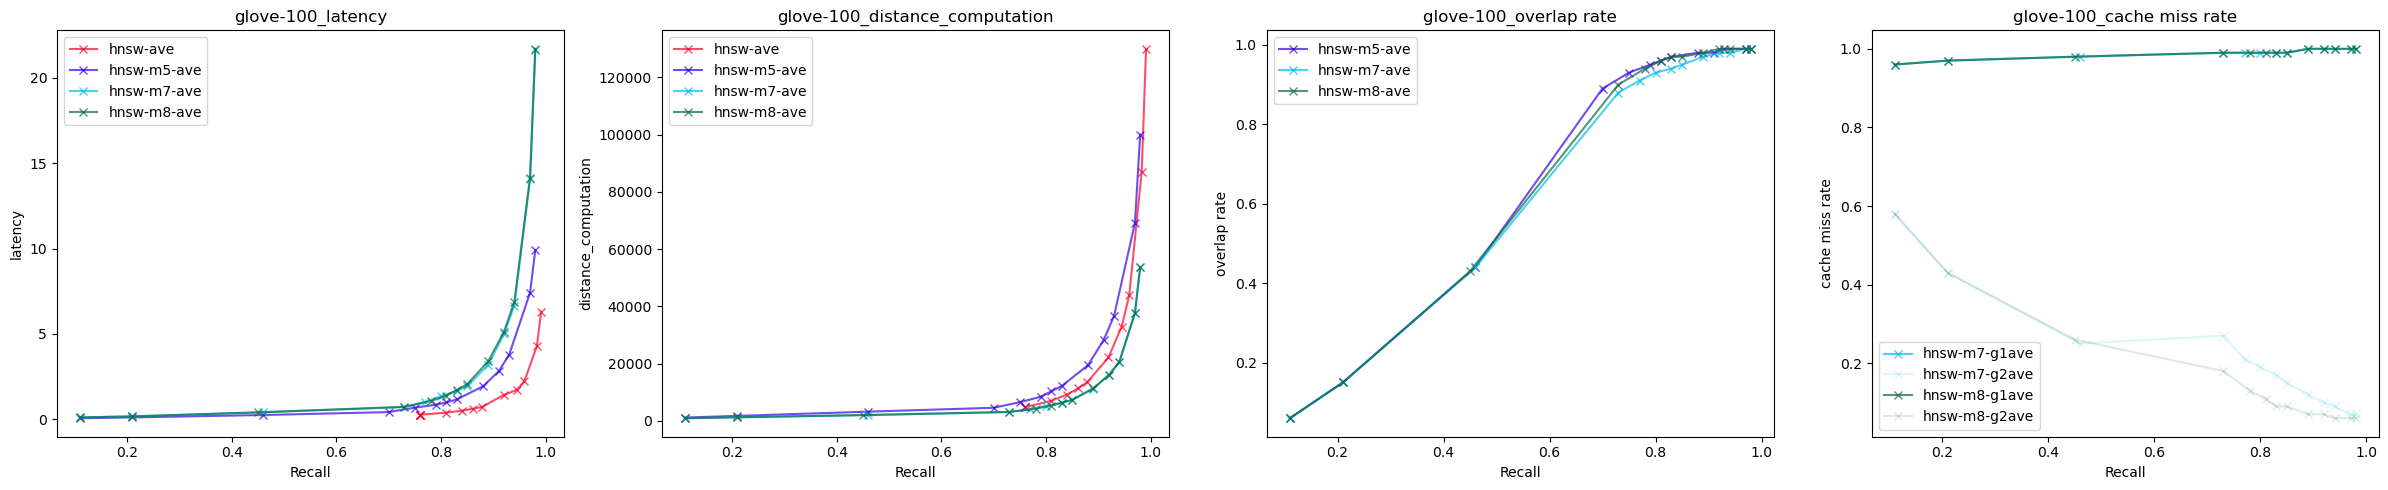

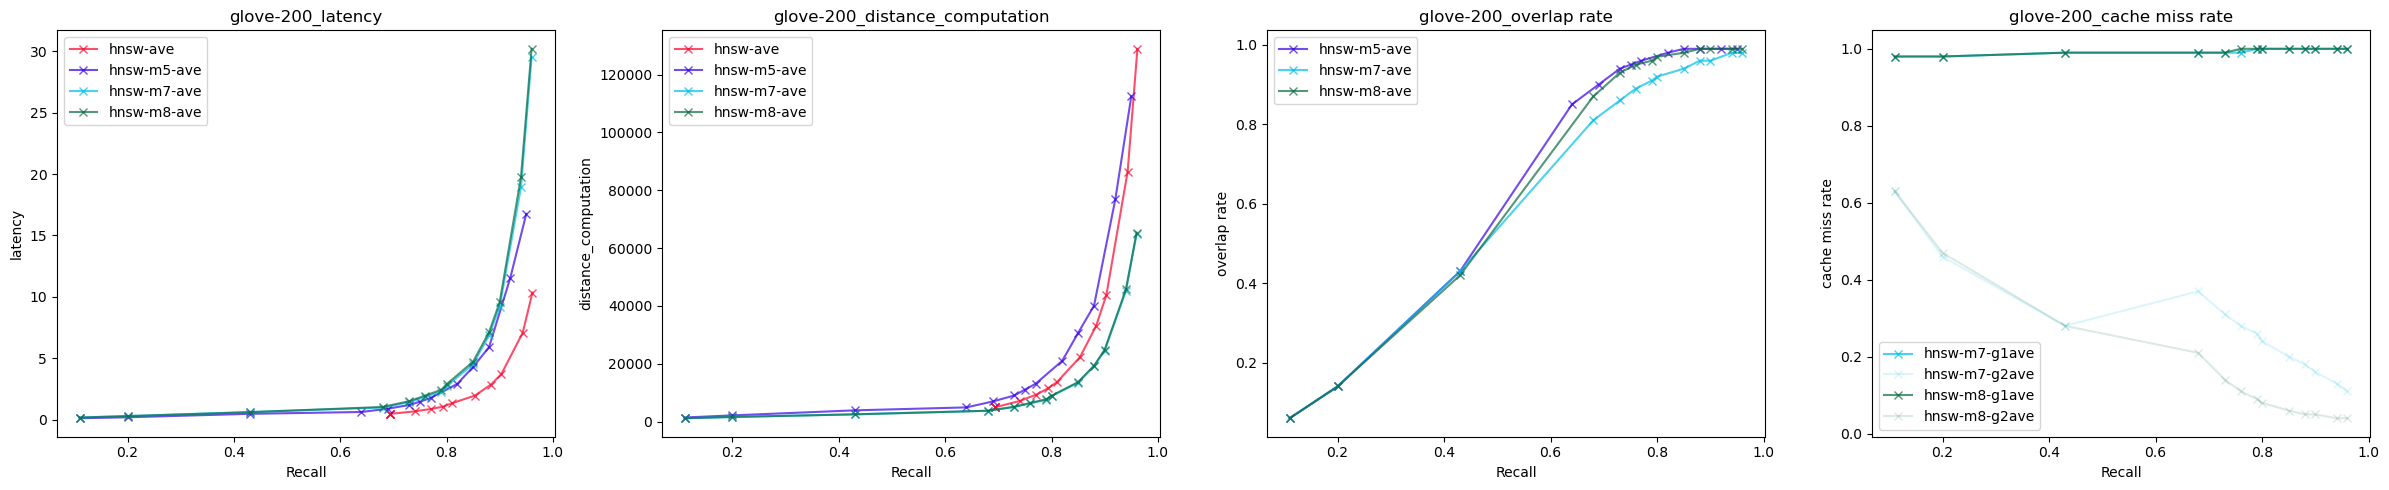

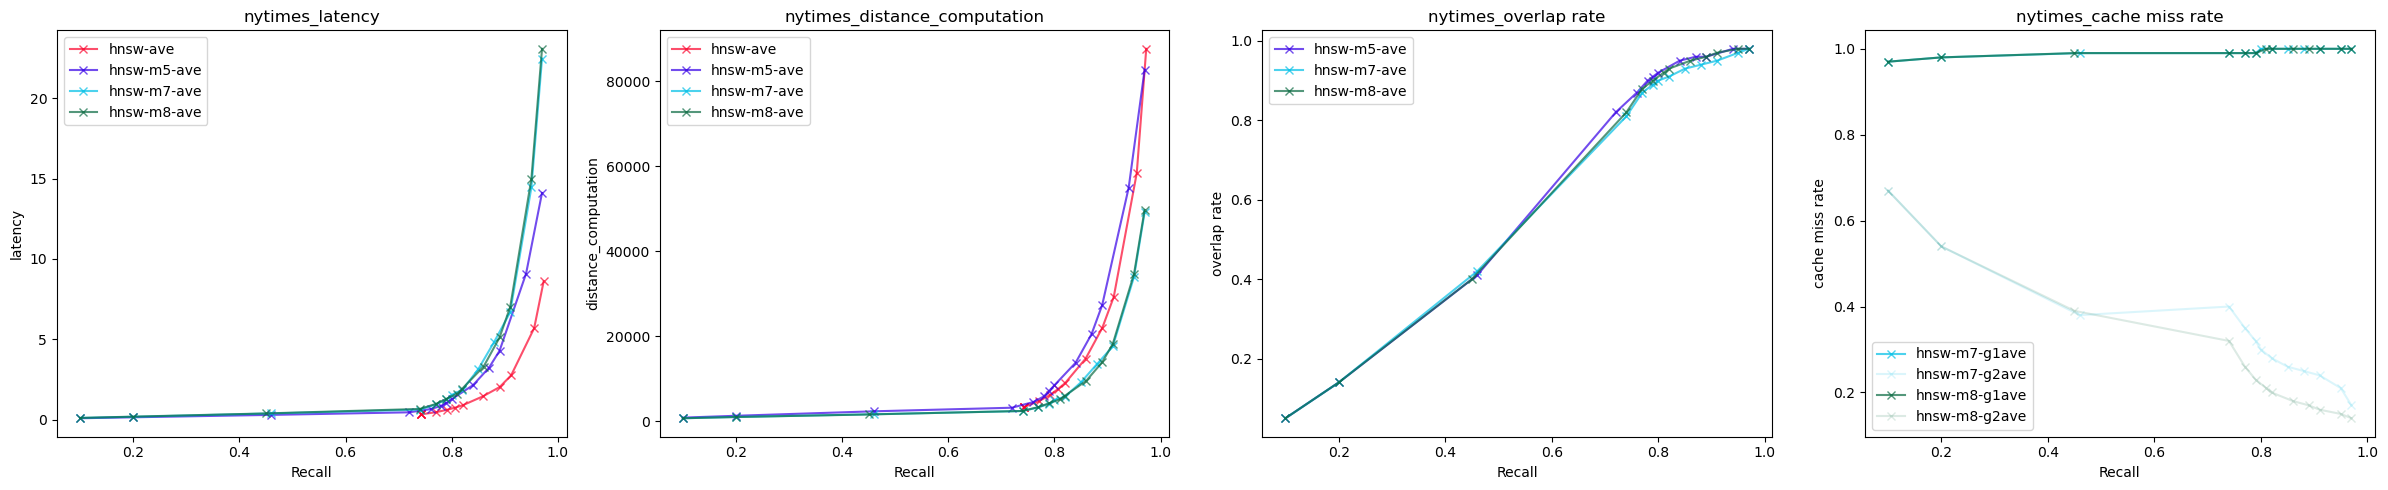

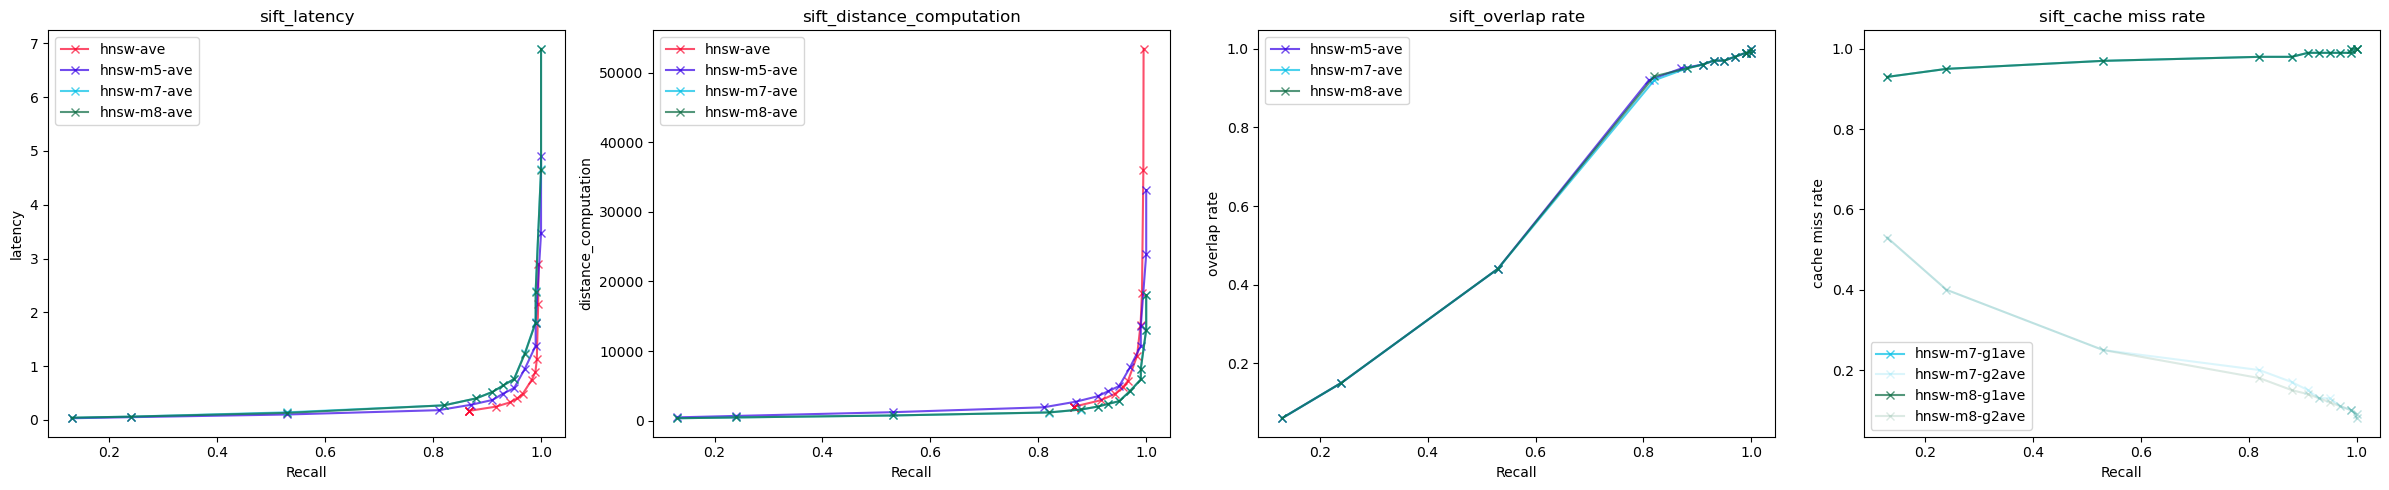

In [15]:
plot_n_m578(datasets)